# UTS TEXT MINING

### Nama: Farren Angelica Dinzani
### NIM: 2702243546
### Link Video: https://youtu.be/_CjFGn0xR0o?si=wo9wiNmHjbR56NbY

In [1]:
from google_play_scraper import reviews, Sort
from wordcloud import WordCloud
from collections import Counter
from nltk import pos_tag
from nltk.corpus import stopwords, words, wordnet
from nltk.stem import WordNetLemmatizer
from gensim.models import KeyedVectors, Word2Vec

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from sklearn.preprocessing import normalize, LabelEncoder
from sklearn.decomposition import PCA
from imblearn.over_sampling import RandomOverSampler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
import os
import random
import seaborn as sns
import enchant
import gensim.downloader as api
import contractions

import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('words')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

/Users/farrenangelica/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/farrenangelica/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     /Users/farrenangelica/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/farrenangelica/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/farrenangelica/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/farrenangelica/nltk_data...
[nltk_data]   Package omw-1.4 

# NO 1 SCRAPING DATA

Pada tahap ini, saya mengumpulkan data review dari **3 game bertema simulation**, yaitu:

- Roblox 
- BitLife
- The Sims FreePlay

Alasannya karena ketiga game ini sama-sama bergenre *simulation*, tapi punya gaya bermain dan karakter pemain yang berbeda.  
Dengan begitu, data yang dikumpulkan jadi lebih beragam, baik dari segi gaya bahasa, panjang ulasan, maupun variasi rating.

Untuk itu, saya melakukan scraping sebanyak **sekitar 1000 data review** (kurang lebih 350 review per game) menggunakan library `google-play-scraper`.  
Semua review diambil dalam bahasa Inggris agar konsisten dengan proses NLP dan mudah dianalisis menggunakan model bahasa umum.

Output dari tahap ini berupa file `simulation_reviews.csv` yang berisi kolom:

- reviewId
- userName
- rating
- at
- review
- app_id
- app_name

Dataset inilah yang nantinya akan digunakan untuk EDA, preprocessing, text representation, dan model prediksi rating.

In [2]:
#apps = {
#    "Roblox": "com.roblox.client",
#    "BitLife": "com.candywriter.bitlife",
#    "The Sims FreePlay": "com.ea.games.simsfreeplay_na"
#}


In [3]:
# function untuk scraping review per game
#def get_reviews(app_id, n=350):
#    result, _ = reviews(
#        app_id,
#        lang='en', 
#        country='us',
#        sort=Sort.NEWEST,
#        count=n
#    )
    
#    df = pd.DataFrame(result)
#    df = df[['reviewId', 'userName', 'score', 'at', 'content']]
#    df['app_id'] = app_id
#    return df

In [4]:
# scrape review dari ketiga game
#dfs = []
#for name, app_id in apps.items():
#    print(f"Scraping reviews for: {name}")
#    df = get_reviews(app_id, n=350)
#    df['app_name'] = name
#    dfs.append(df)

In [5]:
# gabung semua data
#reviews_df = pd.concat(dfs, ignore_index=True)
#reviews_df.head()

In [6]:
# save data --> CSV
#reviews_df.rename(columns={'content': 'review', 'score': 'rating'}, inplace=True)
#reviews_df.to_csv('simulation_reviews.csv', index=False, encoding='utf-8')

# NO 2 EDA

Setelah proses scraping, langkah berikutnya adalah melakukan Exploratory Data Analysis (EDA) untuk memahami struktur dan kualitas data yang sudah dikumpulkan.

Dataset yang digunakan bernama `simulation_reviews.csv`, hasil gabungan dari review tiga game bertema simulation (Roblox, BitLife, dan The Sims FreePlay).

In [7]:
df = pd.read_csv('simulation_reviews.csv')

In [8]:
print("Jumlah data:", len(df))
df.head()

Jumlah data: 1050


,reviewId,userName,rating,at,review,app_id,app_name
0,50f303ec-51fb-4498-a384-46b337629222,Premlata Bindal,5,2025-11-07 22:25:20,my sister exploded while playing some game do ...,com.roblox.client,Roblox
1,b0b82689-c8f3-4a6a-88f1-5ddbc28ed766,Victoria Benjamin,5,2025-11-07 22:24:43,Vary nice environment and great way to spend t...,com.roblox.client,Roblox
2,a15b9381-3a13-4a8e-900e-2da4cb381ef5,Lyline Azul,5,2025-11-07 22:23:12,Fun ! 😊,com.roblox.client,Roblox
3,894a2832-a52f-4e70-9607-2f73df613727,Christine Fraser,5,2025-11-07 22:22:38,amazing best games I've played before,com.roblox.client,Roblox
4,4e7380ae-a2c9-43bd-bd8b-8b64150e1a2c,Motim Sahu,4,2025-11-07 22:22:32,no real games,com.roblox.client,Roblox


In [9]:
df.shape

(1050, 7)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   reviewId  1050 non-null   object
 1   userName  1050 non-null   object
 2   rating    1050 non-null   int64 
 3   at        1050 non-null   object
 4   review    1050 non-null   object
 5   app_id    1050 non-null   object
 6   app_name  1050 non-null   object
dtypes: int64(1), object(6)
memory usage: 57.6+ KB


Dari hasil `df.info()` terlihat bahwa:
- Dataset memiliki **1.050 baris** dan **7 kolom**.
- Semua kolom tidak memiliki nilai kosong (`null`), artinya data cukup bersih secara struktur.
- Kolom yang relevan untuk analisis teks adalah `review` (teks ulasan) dan `rating` (nilai bintang 1–5).

In [11]:
df.isnull().sum()

reviewId    0
userName    0
rating      0
at          0
review      0
app_id      0
app_name    0
dtype: int64

In [12]:
duplicates = df.duplicated(subset=['review']).sum()
print(f"Jumlah duplicate: {duplicates}")

Jumlah duplicate: 65


Namun, dari hasil pengecekan ditemukan adanya **65 data duplikat** berdasarkan kolom `review`.  
Duplikat ini bisa berasal dari ulasan yang sama diambil dua kali saat proses scraping, sehingga perlu dihapus di tahap preprocessing nanti.

Distribusi rating:
rating
1    221
2     46
3     75
4     99
5    609
Name: count, dtype: int64


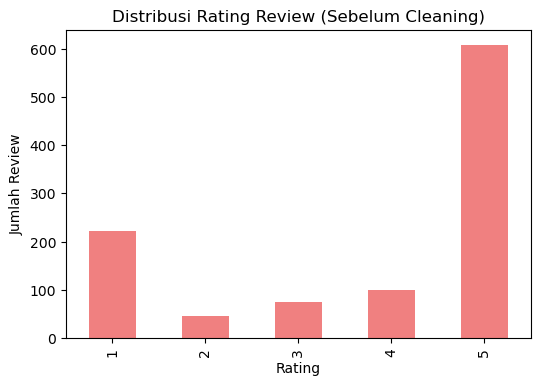

In [13]:
print("Distribusi rating:")
print(df['rating'].value_counts().sort_index())

plt.figure(figsize=(6,4))
df['rating'].value_counts().sort_index().plot(kind='bar', color='lightcoral')
plt.title('Distribusi Rating Review (Sebelum Cleaning)')
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')
plt.show()

Visualisasi di atas menunjukkan distribusi rating sebelum dilakukan pembersihan.

Terlihat bahwa mayoritas pengguna memberikan **rating 5 (positif)**, disusul oleh rating 1 (negatif), sedangkan rating 2-4 jauh lebih sedikit.  
Artinya, data cenderung **imbalanced** karena lebih banyak ulasan positif dibanding netral atau negatif.

Distribusi ini umum terjadi di ulasan aplikasi, karena pengguna lebih sering menulis review saat mereka **sangat puas** atau **sangat kecewa**.  
Ketidakseimbangan ini nantinya akan menjadi pertimbangan penting dalam model machine learning, terutama saat training model agar tidak bias terhadap kelas mayoritas (rating 5).

# NO 3 PREPROCESSING

In [14]:
# pilih kolom yang diperlukan saja
df = df[['review', 'rating', 'app_name']]

Dari dataset awal, hanya kolom `review`, `rating`, dan `app_name` yang digunakan.  
Kolom lain seperti `userName` dan `reviewId` dihapus karena tidak relevan untuk analisis sentimen.

In [15]:
# hapus duplikat
df = df.drop_duplicates(subset=['review'])
print(f"Jumlah data setelah hapus duplikat: {len(df)}")

# hapus review kosong
df = df.dropna(subset=['review'])
df = df[df['review'].str.strip() != ""]

Jumlah data setelah hapus duplikat: 985


Ditemukan 65 duplikat review yang dihapus agar tidak memengaruhi frekuensi kata dan distribusi rating.  
Jumlah data menjadi 985 review.

In [16]:
display(df.head())

,review,rating,app_name
0,my sister exploded while playing some game do ...,5,Roblox
1,Vary nice environment and great way to spend t...,5,Roblox
2,Fun ! 😊,5,Roblox
3,amazing best games I've played before,5,Roblox
4,no real games,4,Roblox


In [ ]:
# text cleaning
def clean_text(text):
    text = contractions.fix(text)
    
    # ubah ke huruf kecil
    text = text.lower()
    
    # hapus URL
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # hapus emoji & simbol unicode
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F700-\U0001F77F"
        u"\U0001F780-\U0001F7FF"
        u"\U0001F800-\U0001F8FF"
        u"\U0001F900-\U0001F9FF"
        u"\U0001FA00-\U0001FA6F"
        u"\U0001FA70-\U0001FAFF"
        u"\u2600-\u26FF"
        u"\u2700-\u27BF"
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)
    
    # hapus karakter selain huruf dan spasi
    text = re.sub(r"[^a-z\s]", "", text)
    
    # hapus spasi berlebih
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df["clean_review"] = df["review"].astype(str).apply(clean_text)

Text Cleaning
   - Mengubah teks menjadi huruf kecil.  
   - Menghapus URL, emoji, dan simbol non-alfabet.  
   - Menghapus spasi berlebih.  
   - Proses ini juga menghapus karakter khusus seperti emotikon dan tanda baca agar teks lebih konsisten.

In [18]:
# stopwords and domain-specific words
stop_words = set(stopwords.words("english"))

# jangan hapus kata negasi penting
negations = {"no", "not", "nor", "never", "none", "cannot"}
stop_words = stop_words - negations

# domain-specific stopwords (tidak relevan secara semantik)
domain_stopwords = {"game", "play", "roblox", "sims", "sim", "app"}

In [19]:
# lemmatization and normalization
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    tag = pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def preprocess_text(text):
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and w not in domain_stopwords and len(w) > 1]
    tokens = [lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in tokens]
    return " ".join(tokens)

df["clean_review"] = df["clean_review"].apply(preprocess_text)

df["clean_review"] = df["clean_review"].apply(
    lambda x: " ".join([w for w in x.split() if w not in domain_stopwords])
)

Stopword removal & Lemmatization
   - Menghapus kata umum yang tidak bermakna (seperti “the”, “is”, “it”) menggunakan stopwords list dari NLTK.  
   - Namun, kata negasi seperti “no”, “not”, “never” tidak dihapus, karena berpengaruh terhadap makna sentimen.  
   - Proses lemmatization dilakukan untuk mengubah kata ke bentuk dasarnya, misalnya: “playing” --> “play”, “loved” --> “love”.
   - Kata-kata yang terlalu umum dalam konteks game seperti “game”, “play”, “app” juga dihapus agar tidak mendominasi.

In [20]:
df = df[df["clean_review"].str.strip() != ""]
print(f"Jumlah data setelah preprocessing: {len(df)}")

Jumlah data setelah preprocessing: 967


Setelah preprocessing penuh, jumlah data menjadi **967 review**.

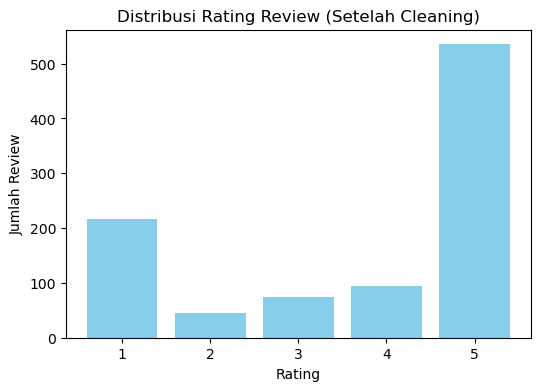

In [21]:
# distribusi rating setelah cleaning
rating_counts = df["rating"].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(rating_counts.index, rating_counts.values, color="skyblue")
plt.xlabel("Rating")
plt.ylabel("Jumlah Review")
plt.title("Distribusi Rating Review (Setelah Cleaning)")
plt.show()

In [22]:
rating_counts = df["rating"].value_counts().sort_index()
rating_percent = (rating_counts / len(df)) * 100

print("Distribusi rating setelah preprocessing:")
print(pd.DataFrame({
    "Rating": rating_counts.index,
    "Jumlah Data": rating_counts.values,
    "Persentase (%)": rating_percent.round(2)
}))

Distribusi rating setelah preprocessing:
        Rating  Jumlah Data  Persentase (%)
rating                                     
1            1          217           22.44
2            2           46            4.76
3            3           75            7.76
4            4           94            9.72
5            5          535           55.33


Distribusi rating setelah proses cleaning menunjukkan hasil yang masih imblance:  
- Rating 5 tetap mendominasi dengan 55%, diikuti rating 1 sebanyak 22%.  
- Hal ini wajar karena user lebih sering memberi ulasan ketika mereka sangat puas atau sangat kecewa.  
- Distribusi ini akan diperhatikan lagi nanti saat proses balancing data.

### Kata dominan per rating

In [23]:
# kata dominan per rating
grouped_text = df.groupby("rating")["clean_review"].apply(lambda x: " ".join(x))
dominant_words = {}

for rating, text in grouped_text.items():
    words_list = [w for w in text.split() if len(w) > 2]
    common_words = Counter(words_list).most_common(10)
    dominant_words[rating] = common_words

    print(f"\nKata dominan untuk rating {rating}:")
    for w, c in common_words:
        print(f"   {w:<15} {c}")


Kata dominan untuk rating 1:
   not             119
   get             43
   update          43
   cannot          32
   pay             32
   money           32
   pack            32
   even            31
   new             29
   like            28

Kata dominan untuk rating 2:
   not             41
   get             23
   like            15
   money           11
   update          9
   new             9
   one             9
   love            8
   time            8
   need            7

Kata dominan untuk rating 3:
   not             41
   like            18
   good            17
   get             16
   make            14
   pay             12
   need            12
   fun             11
   update          10
   money           10

Kata dominan untuk rating 4:
   like            33
   get             23
   not             22
   good            21
   love            17
   time            16
   would           15
   thing           14
   make            14
   really          13

Kata

Untuk memahami karakteristik tiap rating, dilakukan analisis kata paling sering muncul pada setiap kelompok rating.  

- **Rating 1 (Negatif):** kata seperti “not”, “update”, “money”, “cannot”, “pay” sering muncul --> menunjukkan keluhan tentang bug dan sistem pembelian.  
- **Rating 3 (Netral):** terdapat campuran kata positif dan negatif seperti “good”, “fun”, dan “not”, yang menandakan review ambigu.  
- **Rating 5 (Positif):** didominasi oleh “love”, “good”, “fun”, “best”, “great” menandakan review puas dan merekomendasikan game.

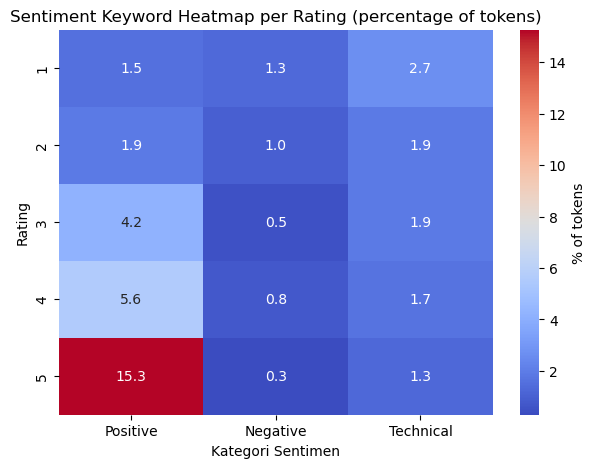

In [24]:
# sentiment keyword heatmap per Rating

sentiment_keywords = {
    "Positive": ["love", "good", "great", "fun", "enjoy", "amazing", "best", "nice"],
    "Negative": ["bad", "boring", "worst", "hate", "terrible", "broken", "crash", "bug"],
    "Technical": ["update", "fix", "slow", "lag", "install", "purchase", "error"]
}

heatmap_data = []
for rating, text in grouped_text.items():
    tokens = text.split()
    total = len(tokens)
    counts = {
        "Positive": sum(w in sentiment_keywords["Positive"] for w in tokens) / total,
        "Negative": sum(w in sentiment_keywords["Negative"] for w in tokens) / total,
        "Technical": sum(w in sentiment_keywords["Technical"] for w in tokens) / total,
    }
    heatmap_data.append([rating, counts["Positive"], counts["Negative"], counts["Technical"]])

heatmap_df = pd.DataFrame(heatmap_data, columns=["Rating", "Positive", "Negative", "Technical"]).set_index("Rating")

plt.figure(figsize=(7,5))
sns.heatmap(heatmap_df*100, annot=True, fmt=".1f", cmap="coolwarm", cbar_kws={'label':'% of tokens'})
plt.title("Sentiment Keyword Heatmap per Rating (percentage of tokens)")
plt.ylabel("Rating")
plt.xlabel("Kategori Sentimen")
plt.show()

Heatmap di atas menunjukkan proporsi kata positif, negatif, dan teknis dalam tiap rating.  
Terlihat pola yang jelas:
- **Rating tinggi (4–5)** memiliki proporsi kata positif yang jauh lebih tinggi.  
- **Rating rendah (1–2)** didominasi kata teknis dan negatif seperti “update”, “bug”, “crash”

Artinya, semakin tinggi rating, semakin sering pengguna menggunakan kata bernada positif. Sementara rating rendah cenderung fokus ke keluhan teknis atau masalah pembelian.

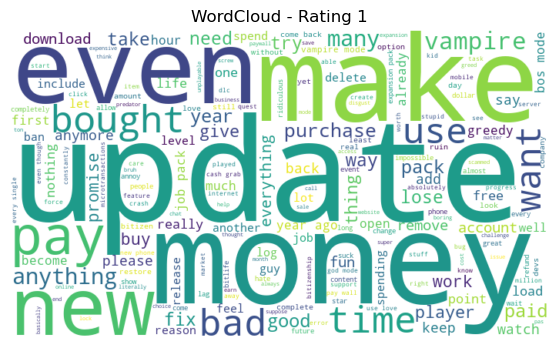

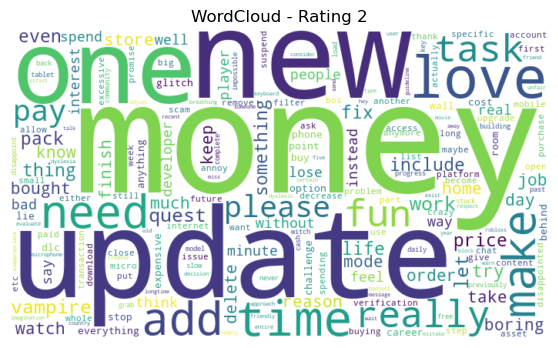

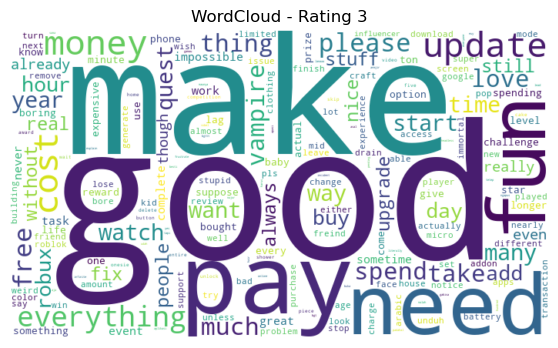

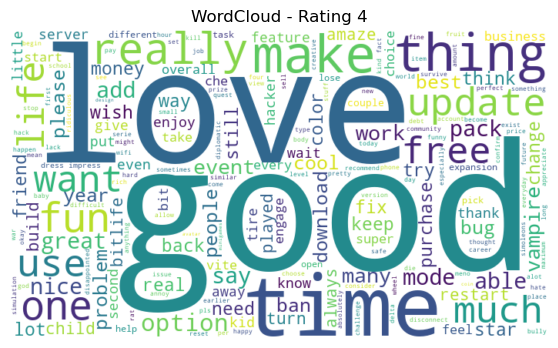

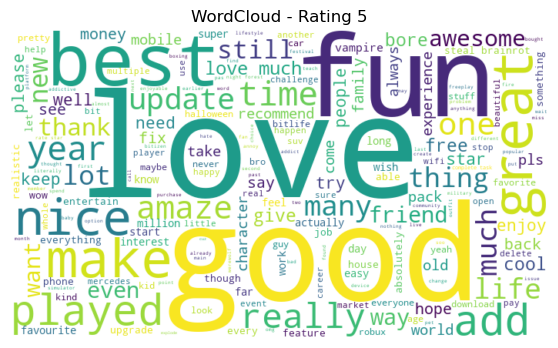

In [25]:
# visualisasi word cloud per rating
for rating, text in grouped_text.items():
    filtered_words = [w for w in text.split() if len(w) > 2]
    wc = WordCloud(width=700, height=400, background_color="white").generate(" ".join(filtered_words))
    plt.figure(figsize=(7,4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud - Rating {rating}")
    plt.show()

Visualisasi WordCloud di atas memperkuat hasil di atas, dengan memperlihatkan kata dominan pada setiap level rating:

- **Rating 1–2:** muncul kata “update”, “money”, “pay” --> menunjukkan ketidakpuasan terhadap fitur dan transaksi.  
- **Rating 3–4:** kata seperti “good”, “love”, “fun” mulai mendominasi --> menandakan pengalaman cukup positif.  
- **Rating 5:** kata “love”, “fun”, “best”, “great” paling sering muncul --> review penuh apresiasi dan kepuasan.

### Kata yang tidak sesuai dengan standar bahasa

In [26]:
# kata tidak sesuai standar bahasa
english_vocab = set(words.words())
all_words = [w for text in df["clean_review"] for w in text.split()]
freq_words = Counter(all_words)
d = enchant.Dict("en_US")

def looks_nonstandard(word):
    if len(word) < 3:
        return True

    vowels = sum(ch in "aeiou" for ch in word)
    if vowels == 0:
        return True

    if re.search(r"(.)\1{3,}", word):
        return True

    if len(set(word)) < 2:
        return True

    return False

nonstandard = {
    w: c for w, c in freq_words.items()
    if (
        len(w) > 2 and c > 2 and 
        not d.check(w) and
        not w in english_vocab and
        looks_nonstandard(w)
    )
}

nonstandard_df = (
    pd.DataFrame(list(nonstandard.items()), columns=["word", "frequency"])
    .sort_values(by="frequency", ascending=False)
    .reset_index(drop=True)
)

print("Kata tidak sesuai standar bahasa:")
display(nonstandard_df.head(20))

Kata tidak sesuai standar bahasa:


,word,frequency
0,pls,14
1,dlc,8
2,bcs,3


In [27]:
# rasio kata non-standar terhadap total kosakata
total_unique_words = len(freq_words)
nonstandard_ratio = len(nonstandard_df) / total_unique_words
print(f"Rasio kata non-standar terhadap total kosakata: {nonstandard_ratio:.2%}")

Rasio kata non-standar terhadap total kosakata: 0.14%


Terakhir, cek kata yang tidak sesuai standar bahasa Inggris (misalnya singkatan atau typo).  
Kata seperti “pls”, “dlc”, dan “bcs” termasuk kategori ini, dengan total rasio hanya **0.14%** dari seluruh kosakata.

Angka ini menunjukkan bahwa teks sudah cukup bersih dan siap untuk tahap text representation

# NO 4 TEXT REPRESENTATION

Setelah data teks dibersihkan, tahap selanjutnya adalah mengubah teks menjadi bentuk numerik (vektor) agar dapat diproses oleh model machine learning.  
Dalam tahap ini digunakan **2 metode representasi teks** yang memiliki prinsip berbeda, yaitu **TF-IDF** dan **Word2Vec (Skip-Gram)**.

In [28]:
df

,review,rating,app_name,clean_review
0,my sister exploded while playing some game do ...,5,Roblox,sister explode not dangerous
1,Vary nice environment and great way to spend t...,5,Roblox,vary nice environment great way spend time family
2,Fun ! 😊,5,Roblox,fun
3,amazing best games I've played before,5,Roblox,amaze best played
4,no real games,4,Roblox,no real
...,...,...,...,...
1045,craft challenges are impossible to beat unless...,1,The Sims FreePlay,craft challenge impossible beat unless spend m...
1046,just dont tell me what to do. I enjoy the game...,5,The Sims FreePlay,not tell enjoy want freedom
1047,you cant afford anything and they just removed...,1,The Sims FreePlay,cannot afford anything remove easy way get mon...
1048,I'm trying to download the latest update but i...,1,The Sims FreePlay,try download late update keep show error no ma...


In [29]:
df.isnull().sum()

review          0
rating          0
app_name        0
clean_review    0
dtype: int64

In [30]:
# data preparation
X = df["clean_review"]
y = df["rating"]

Sebelum proses vektorisasi, rating 1–5 dikonversi menjadi tiga kategori sentimen:
- Rating 1–2 --> Negative
- Rating 3 --> Neutral
- Rating 4–5 --> Positive

In [31]:
# konversi Rating 1–5 --> 3 sentimen
def map_sentiment(rating):
    if rating in [1, 2]:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["sentiment"] = df["rating"].apply(map_sentiment)

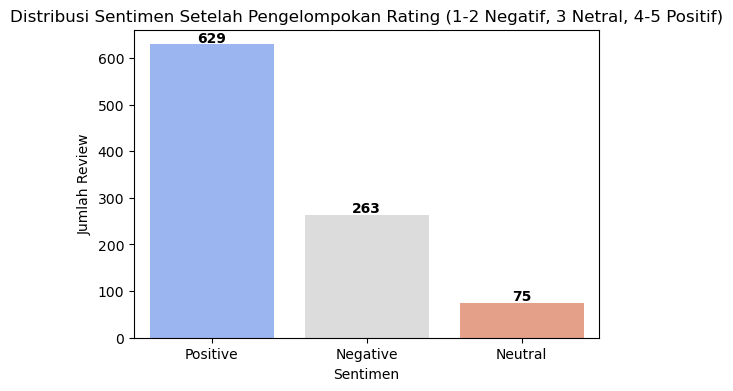

In [32]:
# cek distribusi sentimen
sentiment_counts = df["sentiment"].value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="coolwarm")
plt.title("Distribusi Sentimen Setelah Pengelompokan Rating (1-2 Negatif, 3 Netral, 4-5 Positif)")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Review")
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.show()

In [33]:
X = df["clean_review"]
y = df["sentiment"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

In [34]:
print("Jumlah data per kelas (training):")
print(y_train.value_counts())
print("\nJumlah data per kelas (testing):")
print(y_test.value_counts())

Jumlah data per kelas (training):
sentiment
Positive    503
Negative    210
Neutral      60
Name: count, dtype: int64

Jumlah data per kelas (testing):
sentiment
Positive    126
Negative     53
Neutral      15
Name: count, dtype: int64


### 1. TF-IDF

Metode TF-IDF mengubah teks menjadi matriks berbasis frekuensi kata, dengan bobot yang menunjukkan seberapa penting suatu kata dalam dokumen dibanding seluruh korpus.  
- Kata yang sering muncul di satu review tetapi jarang di review lain --> mendapat bobot tinggi.  
- Kata umum yang sering muncul di semua review --> mendapat bobot rendah.

Pada proyek ini:
- Diambil 2.000 kata paling informatif.  
- Menggunakan unigram (1 kata per token).  

In [35]:
# initialize TF-IDF
tfidf = TfidfVectorizer(
    max_features=2000,     # ambil 2000 kata teratas
    ngram_range=(1, 1),    # unigram
    min_df=2,              # kata harus muncul di >= 5 dokumen
    max_df=0.9             # hapus kata yang terlalu umum
)

In [36]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF shape (train):", X_train_tfidf.shape)
print("TF-IDF shape (test):", X_test_tfidf.shape)

TF-IDF shape (train): (773, 767)
TF-IDF shape (test): (194, 767)


In [37]:
print("Contoh fitur TF-IDF:", tfidf.get_feature_names_out()[:15])

Contoh fitur TF-IDF: ['ability' 'able' 'absolute' 'absolutely' 'accept' 'access' 'accidentally'
 'account' 'act' 'action' 'activity' 'actual' 'actually' 'ad' 'add']


### 2. Word2Vec (Skip Gram)

Berbeda dengan TF-IDF, Word2Vec menggunakan pendekatan neural embedding,  
model ini mempelajari representasi kata berdasarkan konteks kata di sekitarnya.

Dalam proyek ini digunakan pendekatan **Skip-Gram**, yang bertujuan memprediksi konteks dari kata target.  
Parameter utama:
- `vector_size = 300` --> setiap kata diubah menjadi vektor berdimensi 300.  
- `window = 5` --> mempertimbangkan 5 kata di kiri dan kanan.  
- `min_count = 2` --> abaikan kata yang muncul kurang dari 2 kali.

In [38]:
sentences_train = [text.split() for text in X_train]

w2v = Word2Vec(
    sentences=sentences_train,
    vector_size=300,     # ukuran embedding 300 dimensi
    window=5,            # konteks di sekitar kata
    min_count=2,         # ignore kata jarang
    sg=1,                # skip-gram
    workers=4,
    epochs=10,
    seed=SEED
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [39]:
def get_review_vector(text, model, vector_size=300):
    words = text.split()

    valid_words = [w for w in words if w in model.wv.key_to_index]
    if not valid_words:
        return np.zeros(vector_size)

    return np.mean(model.wv[valid_words], axis=0)

In [40]:
X_train_w2v = np.array([get_review_vector(text, w2v, vector_size=w2v.vector_size) for text in X_train])
X_test_w2v  = np.array([get_review_vector(text, w2v, vector_size=w2v.vector_size) for text in X_test])

X_train_w2v = normalize(X_train_w2v)
X_test_w2v  = normalize(X_test_w2v)

print("Word2Vec shape (train):", X_train_w2v.shape)
print("Word2Vec shape (test) :", X_test_w2v.shape)

Word2Vec shape (train): (773, 300)
Word2Vec shape (test) : (194, 300)


In [41]:
# lihat beberapa kata dan vektornya
for word in ["love", "update", "boring", "fun"]:
    if word in w2v.wv.key_to_index:
        try:
            print(f"Most similar to '{word}':", w2v.wv.most_similar(word, topn=5))
        except Exception as e:
            print(f"Could not compute most_similar for '{word}': {e}")
    else:
        print(f"\nWord '{word}' not found in Word2Vec vocab.")

Most similar to 'love': [('far', 0.999241828918457), ('disappointed', 0.9991879463195801), ('use', 0.9991818070411682), ('edit', 0.9991804361343384), ('impress', 0.9991721510887146)]
Most similar to 'update': [('suppose', 0.9992427825927734), ('dollar', 0.9992090463638306), ('paid', 0.9991906881332397), ('yet', 0.9991848468780518), ('content', 0.9991787672042847)]
Most similar to 'boring': [('house', 0.9992473125457764), ('lock', 0.9992412328720093), ('face', 0.9992321133613586), ('expensive', 0.99923175573349), ('leave', 0.9992281794548035)]
Most similar to 'fun': [('far', 0.9992136359214783), ('little', 0.9992020726203918), ('suck', 0.999200701713562), ('chat', 0.9991881251335144), ('help', 0.9991849660873413)]


Walaupun ada beberapa hasil kurang akurat, hal ini wajar karena model dilatih dari awal dengan dataset yang relatif kecil.

In [42]:
# otomatisasi perluasan keyword sentimen
positive_ref = ["good", "love", "fun", "amazing", "great", "enjoy", "nice", "best"]
negative_ref = ["bad", "hate", "boring", "terrible", "bug", "crash", "broken", "lag"]

def similar_words(ref_words, model, topn=15):
    sim_words = []
    for w in ref_words:
        if w in model.wv.key_to_index:
            try:
                sim_words += [w2 for w2, _ in model.wv.most_similar(w, topn=topn)]
            except Exception:
                # skip on any error (rare)
                pass
    return list(set(sim_words))

auto_pos = similar_words(positive_ref, w2v)
auto_neg = similar_words(negative_ref, w2v)

print(f"Jumlah Positive Keywords ditemukan: {len(auto_pos)}")
print(f"Jumlah Negative Keywords ditemukan: {len(auto_neg)}")

Jumlah Positive Keywords ditemukan: 69
Jumlah Negative Keywords ditemukan: 86


In [43]:
# hitung kemunculan otomatis per rating
grouped_text = df.groupby("rating")["clean_review"].apply(lambda x: " ".join(x))
sentiment_counts = []
for rating, text in grouped_text.items():
    tokens = text.split()
    total = len(tokens) if len(tokens) > 0 else 1
    counts = {
        "Positive": sum(w in auto_pos for w in tokens) / total,
        "Negative": sum(w in auto_neg for w in tokens) / total
    }
    sentiment_counts.append([rating, counts["Positive"], counts["Negative"]])

sentiment_auto_df = pd.DataFrame(sentiment_counts, columns=["Rating", "Positive", "Negative"]).set_index("Rating")

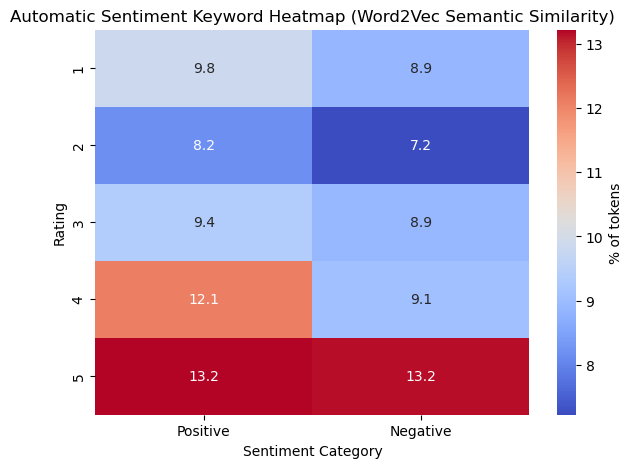

In [44]:
plt.figure(figsize=(7,5))
sns.heatmap(sentiment_auto_df*100, annot=True, fmt=".1f", cmap="coolwarm", cbar_kws={'label': '% of tokens'})
plt.title("Automatic Sentiment Keyword Heatmap (Word2Vec Semantic Similarity)")
plt.xlabel("Sentiment Category")
plt.ylabel("Rating")
plt.show()

Heatmap di atas menggambarkan proporsi kata positif dan negatif berdasarkan kemiripan semantik dari Word2Vec.  
Terlihat bahwa:
- Rating 4 dan 5 memiliki porsi positive tokens tertinggi (12–13%),  
- Sedangkan rating rendah (1–2) memiliki proporsi negative tokens lebih besar (8–9%).  

Hal ini menunjukkan bahwa model Word2Vec mampu menangkap korelasi antara konteks kata dan emosi user,  

| Metode | Pendekatan | Kelebihan | Kekurangan |
|--------|-------------|------------|-------------|
| **TF-IDF** | Statistik (frekuensi kata) | Sederhana, interpretatif, cepat | Tidak menangkap makna konteks antar kata |
| **Word2Vec (Skip-Gram)** | Neural embedding berbasis konteks | Memahami semantik antar kata | Butuh data besar agar representasi stabil |

# NO 5 ML MODEL

Setelah teks direpresentasikan ke dalam bentuk vektor (TF-IDF dan Word2Vec), langkah berikutnya adalah melatih model klasifikasi untuk memprediksi sentimen review (Negative, Neutral, Positive).

Dalam proyek ini digunakan 2 algoritma utama:
1. **Logistic Regression (LR)**  
2. **XGBoost Classifier (XGB)**  

Keduanya dipilih karena karakteristiknya saling melengkapi dan umum digunakan untuk text classification.

### 1. Logistic Regression (LR)

**Alasan Pemilihan LR:**
- Merupakan baseline yang kuat untuk klasifikasi teks berbasis TF-IDF.  
- Cepat, efisien, dan mudah dituning.  
- Memberikan hasil yang mudah diinterpretasikan (koefisien menunjukkan kontribusi tiap fitur).

#### Logistic Regression (TF-IDF Representation)

LR dilatih menggunakan representasi TF-IDF dengan proses hyperparameter tuning menggunakan GridSearchCV.  
Parameter yang dioptimasi:

| Parameter | Nilai Uji | Fungsi |
|------------|------------|---------|
| `C` | [0.01, 0.1, 1] | Mengontrol regularisasi (overfitting prevention) |
| `solver` | ['liblinear', 'lbfgs'] | Algoritma optimasi |
| `max_iter` | [100, 200, 300] | Jumlah iterasi maksimum |

In [45]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

lr_tfidf = LogisticRegression(random_state=SEED)

param_grid_tfidf_lr = {
    "C": [0.01, 0.1, 1],
    "solver": ["liblinear", "lbfgs"],
    "max_iter": [100, 200, 300]
}

grid_tfidf_lr = GridSearchCV(
    LogisticRegression(random_state=SEED),
    param_grid_tfidf_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_tfidf_lr.fit(X_train_tfidf, y_train)
best_lr_tfidf = grid_tfidf_lr.best_estimator_

print("Best Parameters (TF-IDF):", grid_tfidf_lr.best_params_)

/Users/farrenangelica/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/farrenangelica/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/farrenangelica/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/farrenangelica/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/farrenangelica/anaconda3/lib/python3.11/site-packages/pandas/core/arr

Best Parameters (TF-IDF): {'C': 1, 'max_iter': 100, 'solver': 'lbfgs'}


In [46]:
y_pred_tfidf = best_lr_tfidf.predict(X_test_tfidf)

print("Classification Report (TF-IDF + LR):")
print(classification_report(y_test, y_pred_tfidf))

Classification Report (TF-IDF + LR):
              precision    recall  f1-score   support

    Negative       0.81      0.64      0.72        53
     Neutral       0.00      0.00      0.00        15
    Positive       0.80      0.96      0.87       126

    accuracy                           0.80       194
   macro avg       0.54      0.53      0.53       194
weighted avg       0.74      0.80      0.76       194



In [47]:
train_acc_tfidf_lr = accuracy_score(y_train, best_lr_tfidf.predict(X_train_tfidf))
test_acc_tfidf_lr = accuracy_score(y_test, y_pred_tfidf)
print(f"TF-IDF + Logistic Regression:")
print(f"Train Accuracy: {train_acc_tfidf_lr:.4f}")
print(f"Test Accuracy : {test_acc_tfidf_lr:.4f}")

if train_acc_tfidf_lr - test_acc_tfidf_lr > 0.05:
    print("⚠️ Model kemungkinan overfitting.")
elif test_acc_tfidf_lr - train_acc_tfidf_lr > 0.05:
    print("⚠️ Model kemungkinan underfitting.")
else:
    print("✅ Model tampak seimbang (good fit).")


TF-IDF + Logistic Regression:
Train Accuracy: 0.8771
Test Accuracy : 0.7990
⚠️ Model kemungkinan overfitting.


**Interpretasi:**
- Model cukup akurat dalam mengenali sentimen positif (recall 0.96, f1-score 0.87).  
- Namun, kelas netral gagal terdeteksi (0.00 f1-score), kemungkinan karena jumlah datanya yang sangat sedikit (hanya 15 sampel).  
- Selisih akurasi train dan test menunjukkan overfitting ringan, di mana model terlalu menyesuaikan data train.

#### Logistic Regression (Word2Vec Skip Gram)

In [48]:
lr_w2v = LogisticRegression(random_state=SEED)

param_grid_w2v_lr = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "saga"],
    "max_iter": [100, 200, 300]
}

grid_w2v_lr = GridSearchCV(
    LogisticRegression(random_state=SEED),
    param_grid_w2v_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_w2v_lr.fit(X_train_w2v, y_train)
best_lr_w2v = grid_w2v_lr.best_estimator_

print("Best Parameters (Word2Vec):", grid_w2v_lr.best_params_)

Best Parameters (Word2Vec): {'C': 0.01, 'max_iter': 100, 'solver': 'lbfgs'}


In [49]:
y_pred_w2v = best_lr_w2v.predict(X_test_w2v)

print("Classification Report (Word2Vec + LR):")
print(classification_report(y_test, y_pred_w2v))

Classification Report (Word2Vec + LR):
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        53
     Neutral       0.00      0.00      0.00        15
    Positive       0.65      1.00      0.79       126

    accuracy                           0.65       194
   macro avg       0.22      0.33      0.26       194
weighted avg       0.42      0.65      0.51       194



In [50]:
train_acc_w2v_lr = accuracy_score(y_train, best_lr_w2v.predict(X_train_w2v))
test_acc_w2v_lr = accuracy_score(y_test, y_pred_w2v)
print(f"Word2Vec + Logistic Regression:")
print(f"Train Accuracy: {train_acc_w2v_lr:.4f}")
print(f"Test Accuracy : {test_acc_w2v_lr:.4f}")

if train_acc_w2v_lr - test_acc_w2v_lr > 0.05:
    print("⚠️ Model kemungkinan overfitting.")
elif test_acc_w2v_lr - train_acc_w2v_lr > 0.05:
    print("⚠️ Model kemungkinan underfitting.")
else:
    print("✅ Model tampak seimbang (good fit).")

Word2Vec + Logistic Regression:
Train Accuracy: 0.6507
Test Accuracy : 0.6495
✅ Model tampak seimbang (good fit).


**Interpretasi:**
- Akurasi menurun dibanding TF-IDF karena Word2Vec dari dataset kecil belum menangkap konteks semantik dengan stabil.  
- Meskipun balanced, model cenderung bias ke kelas positif, dengan recall 1.00 (semua review diklasifikasikan positif).  
- Namun, model ini tetap berguna sebagai pembanding karena memanfaatkan informasi konteks antar kata.

### 2. XGBoost

**Alasan Pemilihan XGBoost:**
- Algoritma gradient boosting yang kuat dan efisien.  
- Mampu menangkap interaksi non linear antar fitur.  
- Umumnya memberikan performa lebih tinggi dibanding model linear pada dataset teks yang kompleks.  

Sebelum melatih model, label `Negative`, `Neutral`, `Positive` dikonversi ke bentuk numerik menggunakan LabelEncoder:

In [51]:
# initialize LabelEncoder
le = LabelEncoder()

# encode label string --> numerik
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [52]:
# cek hasil encoding
print("Mapping Label Encoder:")
for cls, code in zip(le.classes_, range(len(le.classes_))):
    print(f"{cls} --> {code}")

print("\nDistribusi label setelah encoding (train):")
print(pd.Series(y_train_encoded).value_counts().sort_index())

Mapping Label Encoder:
Negative --> 0
Neutral --> 1
Positive --> 2

Distribusi label setelah encoding (train):
0    210
1     60
2    503
Name: count, dtype: int64


#### XGBoost (TF-IDF Representation)

**Parameter yang di test (Grid Search):**

| Parameter | Nilai Uji | Fungsi |
|------------|------------|---------|
| `n_estimators` | [100, 200] | Jumlah trees |
| `max_depth` | [3, 5] | Kedalaman maksimum tiap tree |
| `learning_rate` | [0.05, 0.1] | Laju pembelajaran |
| `subsample` | [0.8, 1.0] | Persentase data yang digunakan per iterasi |

In [53]:
xgb_tfidf = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    random_state=SEED,
    eval_metric='mlogloss',
    use_label_encoder=False
)

param_grid_tfidf_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_tfidf_xgb = GridSearchCV(
    XGBClassifier(
        objective='multi:softmax',
        num_class=len(le.classes_),
        random_state=SEED,
        eval_metric='mlogloss',
        use_label_encoder=False
    ),
    param_grid_tfidf_xgb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_tfidf_xgb.fit(X_train_tfidf, y_train_encoded)
best_xgb_tfidf = grid_tfidf_xgb.best_estimator_

print("\nBest Params (TF-IDF):", grid_tfidf_xgb.best_params_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best Params (TF-IDF): {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}


In [54]:
y_pred_tfidf_xgb = best_xgb_tfidf.predict(X_test_tfidf)
y_pred_tfidf_xgb = le.inverse_transform(y_pred_tfidf_xgb)

print("\nClassification Report (TF-IDF + XGB):")
print(classification_report(y_test, y_pred_tfidf_xgb))


Classification Report (TF-IDF + XGB):
              precision    recall  f1-score   support

    Negative       0.63      0.55      0.59        53
     Neutral       0.00      0.00      0.00        15
    Positive       0.78      0.91      0.84       126

    accuracy                           0.74       194
   macro avg       0.47      0.49      0.48       194
weighted avg       0.68      0.74      0.71       194



In [55]:
train_acc_tfidf_xgb = accuracy_score(y_train_encoded, best_xgb_tfidf.predict(X_train_tfidf))
test_acc_tfidf_xgb = accuracy_score(y_test, y_pred_tfidf_xgb)
print(f"TF-IDF + XGBoost:")
print(f"Train Accuracy: {train_acc_tfidf_xgb:.4f}")
print(f"Test Accuracy : {test_acc_tfidf_xgb:.4f}")

if train_acc_tfidf_xgb - test_acc_tfidf_xgb > 0.05:
    print("⚠️ Model kemungkinan overfitting.")
elif test_acc_tfidf_xgb - train_acc_tfidf_xgb > 0.05:
    print("⚠️ Model kemungkinan underfitting.")
else:
    print("✅ Model tampak seimbang (good fit).")

TF-IDF + XGBoost:
Train Accuracy: 0.9107
Test Accuracy : 0.7423
⚠️ Model kemungkinan overfitting.


**Interpretasi:**
- Model bekerja cukup baik untuk mendeteksi sentimen positif (f1-score 0.84).  
- Namun performa untuk kelas netral kembali rendah.  
- Overfitting terjadi karena model terlalu kompleks dibanding ukuran data (773 data train).

#### XGBoost (Word2Vec Skip Gram)

In [56]:
xgb_w2v = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    random_state=SEED,
    eval_metric='mlogloss',
    use_label_encoder=False
)

param_grid_w2v_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7],
    'learning_rate': [0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_w2v_xgb = GridSearchCV(
    XGBClassifier(
        objective='multi:softmax',
        num_class=len(le.classes_),
        random_state=SEED,
        eval_metric='mlogloss',
        use_label_encoder=False
    ),
    param_grid_w2v_xgb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_w2v_xgb.fit(X_train_w2v, y_train_encoded)
best_xgb_w2v = grid_w2v_xgb.best_estimator_

print("\nBest Params (Word2Vec):", grid_w2v_xgb.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best Params (Word2Vec): {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}


In [57]:
y_pred_w2v_xgb = best_xgb_w2v.predict(X_test_w2v)
y_pred_w2v_xgb = le.inverse_transform(y_pred_w2v_xgb)

print("Classification Report (Word2Vec + XGB):")
print(classification_report(y_test, y_pred_w2v_xgb))

Classification Report (Word2Vec + XGB):
              precision    recall  f1-score   support

    Negative       0.68      0.60      0.64        53
     Neutral       0.00      0.00      0.00        15
    Positive       0.80      0.93      0.86       126

    accuracy                           0.77       194
   macro avg       0.49      0.51      0.50       194
weighted avg       0.71      0.77      0.73       194



In [58]:
train_acc_w2v_xgb = accuracy_score(y_train_encoded, best_xgb_w2v.predict(X_train_w2v))
test_acc_w2v_xgb = accuracy_score(y_test, y_pred_w2v_xgb)
print(f"Word2Vec + XGBoost:")
print(f"Train Accuracy: {train_acc_w2v_xgb:.4f}")
print(f"Test Accuracy : {test_acc_w2v_xgb:.4f}")

if train_acc_w2v_xgb - test_acc_w2v_xgb > 0.05:
    print("⚠️ Model kemungkinan overfitting.")
elif test_acc_w2v_xgb - train_acc_w2v_xgb > 0.05:
    print("⚠️ Model kemungkinan underfitting.")
else:
    print("✅ Model tampak seimbang (good fit).")

Word2Vec + XGBoost:
Train Accuracy: 0.9948
Test Accuracy : 0.7680
⚠️ Model kemungkinan overfitting.


**Interpretasi:**
- Hasil serupa dengan versi TF-IDF, namun sedikit lebih baik di test set.  
- Model sangat kuat dalam mempelajari pola data train (train acc hampir 100%), namun tidak mampu mempertahankan generalisasi di data test.  

### Kesimpulan ML Model
- Logistic Regression + TF-IDF memberikan hasil terbaik secara stabil dan interpretatif.  
- XGBoost memang menghasilkan akurasi tinggi di train set, tetapi cenderung overfitting pada data test.  
- Performa untuk kelas neutral tetap lemah karena distribusi data yang tidak seimbang.  

# NO 6 COMPARING PERFORMANCES

In [59]:
# TF-IDF + Logistic Regression
precision_tfidf_lr = precision_score(y_test, y_pred_tfidf, average="weighted", zero_division=0)
recall_tfidf_lr = recall_score(y_test, y_pred_tfidf, average="weighted", zero_division=0)
f1_tfidf_lr = f1_score(y_test, y_pred_tfidf, average="macro", zero_division=0)

# Word2Vec + Logistic Regression
precision_w2v_lr = precision_score(y_test, y_pred_w2v, average="weighted", zero_division=0)
recall_w2v_lr = recall_score(y_test, y_pred_w2v, average="weighted", zero_division=0)
f1_w2v_lr = f1_score(y_test, y_pred_w2v, average="macro", zero_division=0)

# TF-IDF + XGBoost
precision_tfidf_xgb = precision_score(y_test, y_pred_tfidf_xgb, average="weighted", zero_division=0)
recall_tfidf_xgb = recall_score(y_test, y_pred_tfidf_xgb, average="weighted", zero_division=0)
f1_tfidf_xgb = f1_score(y_test, y_pred_tfidf_xgb, average="macro", zero_division=0)

# Word2Vec + XGBoost
precision_w2v_xgb = precision_score(y_test, y_pred_w2v_xgb, average="weighted", zero_division=0)
recall_w2v_xgb = recall_score(y_test, y_pred_w2v_xgb, average="weighted", zero_division=0)
f1_w2v_xgb = f1_score(y_test, y_pred_w2v_xgb, average="macro", zero_division=0)

In [60]:
# buat tabel summary hasil evaluasi
summary_data = {
    "Text Representation": ["TF-IDF", "TF-IDF", "Word2Vec (Skip Gram)", "Word2Vec (Skip Gram)"],
    "Algoritma Machine Learning": [
        "Logistic Regression (LR)",
        "XGBoost (XGB)",
        "Logistic Regression (LR)",
        "XGBoost (XGB)"
    ],
    "Machine Learning Hyperparameter": [
        str(grid_tfidf_lr.best_params_),
        str(grid_tfidf_xgb.best_params_),
        str(grid_w2v_lr.best_params_),
        str(grid_w2v_xgb.best_params_)
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_tfidf),
        accuracy_score(y_test, y_pred_tfidf_xgb),
        accuracy_score(y_test, y_pred_w2v),
        accuracy_score(y_test, y_pred_w2v_xgb)
    ],
    "Precision (weighted avg)": [
        precision_tfidf_lr,
        precision_tfidf_xgb,
        precision_w2v_lr,
        precision_w2v_xgb
    ],
    "Recall (weighted avg)": [
        recall_tfidf_lr,
        recall_tfidf_xgb,
        recall_w2v_lr,
        recall_w2v_xgb
    ],
    "F1-score (macro avg)": [
        f1_tfidf_lr,
        f1_tfidf_xgb,
        f1_w2v_lr,
        f1_w2v_xgb
    ]
}

summary_df = pd.DataFrame(summary_data)

In [61]:
display(
    summary_df.style
        .set_caption("Tabel Perbandingan Performa Model dengan Metode Text Representation Berbeda")
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([{
            'selector': 'caption',
            'props': [('text-align', 'center'),
                      ('font-weight', 'bold'),
                      ('font-size', '14px')]
        }])
)

,Text Representation,Algoritma Machine Learning,Machine Learning Hyperparameter,Accuracy,Precision (weighted avg),Recall (weighted avg),F1-score (macro avg)
0,TF-IDF,Logistic Regression (LR),"{'C': 1, 'max_iter': 100, 'solver': 'lbfgs'}",0.798969,0.738182,0.798969,0.528764
1,TF-IDF,XGBoost (XGB),"{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}",0.742268,0.676899,0.742268,0.475092
2,Word2Vec (Skip Gram),Logistic Regression (LR),"{'C': 0.01, 'max_iter': 100, 'solver': 'lbfgs'}",0.649485,0.421830,0.649485,0.262500
3,Word2Vec (Skip Gram),XGBoost (XGB),"{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}",0.768041,0.706483,0.768041,0.500098


- **TF-IDF + Logistic Regression** adalah kombinasi terbaik untuk dataset review berukuran kecil hingga menengah. Model ini sederhana, efisien, dan memberikan hasil yang paling konsisten.  
- **Word2Vec + XGBoost** memiliki potensi bagus jika jumlah data jauh lebih besar, karena mampu menangkap makna kontekstual antar kata yang tidak bisa dilakukan oleh TF-IDF.  
- F1-score macro yang relatif rendah pada seluruh model (sekitar 0.5) menunjukkan bahwa kelas “Neutral” masih sulit diprediksi.

# NO 7 DATA IMBALANCE

### Distribusi Data

In [62]:
# hitung distribusi data
rating_counts = y.value_counts().sort_index()
rating_percent = (rating_counts / len(y)) * 100

rating_dist_df = pd.DataFrame({
    "Rating": rating_counts.index,
    "Jumlah Data": rating_counts.values,
    "Persentase (%)": rating_percent.values.round(2)
})

display(rating_dist_df)

,Rating,Jumlah Data,Persentase (%)
0,Negative,263,27.20
1,Neutral,75,7.76
2,Positive,629,65.05


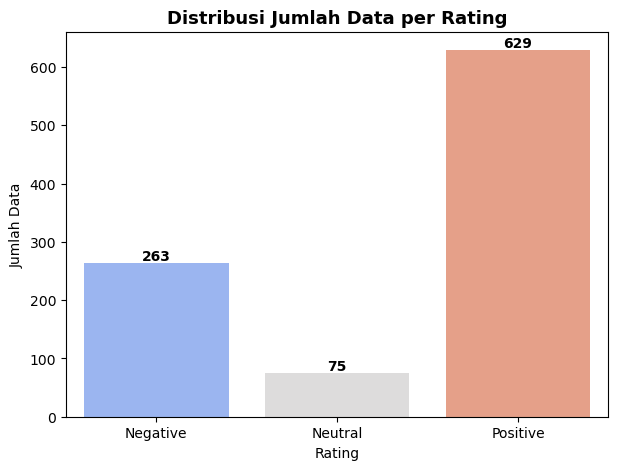

In [63]:
# visualisasi distribusi data per rating
plt.figure(figsize=(7,5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="coolwarm")
plt.title("Distribusi Jumlah Data per Rating", fontsize=13, fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Jumlah Data")
for i, v in enumerate(rating_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.show()

## Handle Imbalance

Tahap ini dilakukan untuk mengatasi data imbalance pada dataset review.  
Masalah imbalance dapat menyebabkan model lebih sering memprediksi kelas mayoritas (positif), sementara mengabaikan kelas minoritas (negatif dan netral).

### RandomOverSampler

Beberapa pendekatan dilakukan untuk mengatasi masalah ini:

a. **TF-IDF + RandomOverSampler**
Teknik oversampling menambah jumlah data kelas minoritas (Negative & Neutral) dengan cara menduplikasi data yang ada hingga seimbang dengan kelas mayoritas.  

In [64]:
ros = RandomOverSampler(random_state=SEED)
X_train_tfidf_res, y_train_tfidf_res = ros.fit_resample(X_train_tfidf, y_train)

print("Distribusi Sebelum Oversampling:", Counter(y_train))
print("Distribusi Setelah Oversampling:", Counter(y_train_tfidf_res))

Distribusi Sebelum Oversampling: Counter({'Positive': 503, 'Negative': 210, 'Neutral': 60})
Distribusi Setelah Oversampling: Counter({'Positive': 503, 'Negative': 503, 'Neutral': 503})


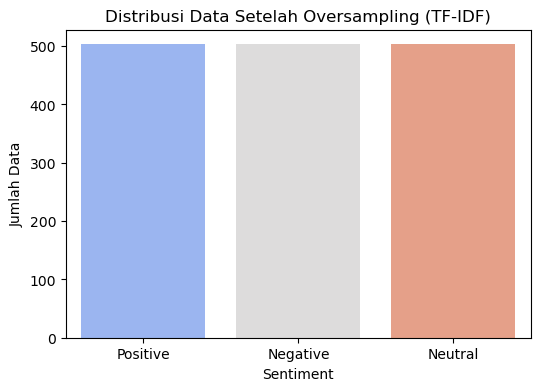

In [65]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=list(Counter(y_train_tfidf_res).keys()), 
    y=list(Counter(y_train_tfidf_res).values()), 
    palette="coolwarm"
)
plt.title("Distribusi Data Setelah Oversampling (TF-IDF)")
plt.xlabel("Sentiment")
plt.ylabel("Jumlah Data")
plt.show()

### Retrain LR (TF-IDF + RandomOverSampler)

In [66]:
lr_tfidf_resampled = LogisticRegression(
    random_state=SEED, 
    **grid_tfidf_lr.best_params_
)

lr_tfidf_resampled.fit(X_train_tfidf_res, y_train_tfidf_res)
y_pred_tfidf_res = lr_tfidf_resampled.predict(X_test_tfidf)

print("Classification Report Retrain (TF-IDF + LR):")
print(classification_report(y_test, y_pred_tfidf_res))

Classification Report Retrain (TF-IDF + LR):
              precision    recall  f1-score   support

    Negative       0.73      0.72      0.72        53
     Neutral       0.11      0.13      0.12        15
    Positive       0.88      0.86      0.87       126

    accuracy                           0.76       194
   macro avg       0.57      0.57      0.57       194
weighted avg       0.78      0.76      0.77       194



### Retrain XGB (TF-IDF + RandomOverSampler)

In [67]:
xgb_tfidf_resampled = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False,
    **grid_tfidf_xgb.best_params_
)

y_train_tfidf_res_enc = le.transform(y_train_tfidf_res)

xgb_tfidf_resampled.fit(X_train_tfidf_res, y_train_tfidf_res_enc)
y_pred_tfidf_xgb_res = xgb_tfidf_resampled.predict(X_test_tfidf)
y_pred_tfidf_xgb_res = le.inverse_transform(y_pred_tfidf_xgb_res)

print("Classification Report Retrain (TF-IDF + XGB):")
print(classification_report(y_test, y_pred_tfidf_xgb_res))

Classification Report Retrain (TF-IDF + XGB):
              precision    recall  f1-score   support

    Negative       0.65      0.70      0.67        53
     Neutral       0.25      0.13      0.17        15
    Positive       0.85      0.87      0.86       126

    accuracy                           0.77       194
   macro avg       0.58      0.57      0.57       194
weighted avg       0.75      0.77      0.76       194



### Class Weight Balancing

- Untuk Word2Vec, dilakukan pendekatan berbeda karena datanya tidak bisa di-resample langsung.  
- Logistic Regression menggunakan `class_weight='balanced'` agar bobot loss per kelas menyesuaikan jumlah datanya.  
- XGBoost diberi `sample_weight` yang proporsional terhadap jumlah data di tiap kelas.

### Retrain LR (Word2Vec + class_weight='balanced')

In [68]:
lr_w2v_bal = LogisticRegression(
    random_state=SEED,
    class_weight='balanced',
    **grid_w2v_lr.best_params_
)

lr_w2v_bal.fit(X_train_w2v, y_train)
y_pred_w2v_bal = lr_w2v_bal.predict(X_test_w2v)

print("Classification Report (Word2Vec + LR Balanced):")
print(classification_report(y_test, y_pred_w2v_bal))

Classification Report (Word2Vec + LR Balanced):
              precision    recall  f1-score   support

    Negative       0.33      0.08      0.12        53
     Neutral       0.07      0.87      0.14        15
    Positive       0.88      0.06      0.10       126

    accuracy                           0.12       194
   macro avg       0.43      0.33      0.12       194
weighted avg       0.67      0.12      0.11       194



### Retrain XGB (Word2Vec + sample_weight)

In [69]:
# Hitung bobot kelas proporsional
class_counts = y_train.value_counts().sort_index()
scale_weights = (max(class_counts) / class_counts).to_dict()
sample_weights = y_train.map(scale_weights)

y_train_w2v_enc = le.transform(y_train)

xgb_w2v_bal = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    random_state=SEED,
    eval_metric='mlogloss',
    use_label_encoder=False,
    **grid_w2v_xgb.best_params_
)

xgb_w2v_bal.fit(X_train_w2v, y_train_w2v_enc, sample_weight=sample_weights)
y_pred_w2v_xgb_bal = xgb_w2v_bal.predict(X_test_w2v)
y_pred_w2v_xgb_bal = le.inverse_transform(y_pred_w2v_xgb_bal)

print("Classification Report (Word2Vec + XGB Balanced):")
print(classification_report(y_test, y_pred_w2v_xgb_bal))

Classification Report (Word2Vec + XGB Balanced):
              precision    recall  f1-score   support

    Negative       0.71      0.70      0.70        53
     Neutral       0.00      0.00      0.00        15
    Positive       0.83      0.92      0.87       126

    accuracy                           0.79       194
   macro avg       0.51      0.54      0.53       194
weighted avg       0.73      0.79      0.76       194



### Tabel Perbandingan Evaluasi Performance

In [70]:
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_true, y_pred, average="macro", zero_division=0)
    }

In [71]:
# 1. Tabel TF-IDF sebelum dan sesudah Oversampling
results_tfidf_compare = {
    "TF-IDF + Logistic Regression (Before Oversampling)": get_metrics(y_test, y_pred_tfidf),
    "TF-IDF + Logistic Regression (After Oversampling)": get_metrics(y_test, y_pred_tfidf_res),
    "TF-IDF + XGBoost (Before Oversampling)": get_metrics(y_test, y_pred_tfidf_xgb),
    "TF-IDF + XGBoost (After Oversampling)": get_metrics(y_test, y_pred_tfidf_xgb_res)
}

tfidf_compare_df = pd.DataFrame(results_tfidf_compare).T.reset_index()
tfidf_compare_df.rename(columns={"index": "Model"}, inplace=True)

display(
    tfidf_compare_df.style
    .set_caption("Perbandingan Performa TF-IDF Sebelum & Sesudah Oversampling")
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{
        'selector': 'caption',
        'props': [('text-align', 'center'),
                  ('font-weight', 'bold'),
                  ('font-size', '14px')]
    }])
)

,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + Logistic Regression (Before Oversampling),0.798969,0.738182,0.798969,0.528764
1,TF-IDF + Logistic Regression (After Oversampling),0.762887,0.778061,0.762887,0.569642
2,TF-IDF + XGBoost (Before Oversampling),0.742268,0.676899,0.742268,0.475092
3,TF-IDF + XGBoost (After Oversampling),0.768041,0.750492,0.768041,0.569795


> Setelah oversampling, F1-score kedua model TF-IDF **meningkat** dari 0.52–0.47 menjadi **0.57**,  
> menandakan bahwa model menjadi lebih adil dalam memprediksi semua kelas, termasuk netral.

In [72]:
# 2. Tabel WORD2VEC sebelum dan sesudah balancing
results_w2v_compare = {
    "Word2Vec + Logistic Regression (Before)": get_metrics(y_test, y_pred_w2v),
    "Word2Vec + Logistic Regression (Balanced)": get_metrics(y_test, y_pred_w2v_bal),
    "Word2Vec + XGBoost (Before)": get_metrics(y_test, y_pred_w2v_xgb),
    "Word2Vec + XGBoost (Balanced)": get_metrics(y_test, y_pred_w2v_xgb_bal)
}

w2v_compare_df = pd.DataFrame(results_w2v_compare).T.reset_index()
w2v_compare_df.rename(columns={"index": "Model"}, inplace=True)

display(
    w2v_compare_df.style
    .set_caption("Perbandingan Performa Word2Vec Sebelum & Sesudah Oversampling")
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{
        'selector': 'caption',
        'props': [('text-align', 'center'),
                  ('font-weight', 'bold'),
                  ('font-size', '14px')]
    }])
)

,Model,Accuracy,Precision,Recall,F1-score
0,Word2Vec + Logistic Regression (Before),0.649485,0.421830,0.649485,0.262500
1,Word2Vec + Logistic Regression (Balanced),0.123711,0.665141,0.123711,0.121707
2,Word2Vec + XGBoost (Before),0.768041,0.706483,0.768041,0.500098
3,Word2Vec + XGBoost (Balanced),0.788660,0.732534,0.788660,0.525647


> Terlihat bahwa **Word2Vec + XGBoost Balanced** juga mengalami peningkatan performa meskipun tidak sebesar TF-IDF.  
> Sebaliknya, balancing pada Logistic Regression justru menurunkan performa drastis karena distribusi bobot yang tidak stabil.

### Perbandingan F1-Score 

In [73]:
f1_tfidf_lr_before = f1_tfidf_lr
f1_tfidf_lr_after  = f1_score(y_test, y_pred_tfidf_res, average="macro", zero_division=0)

f1_tfidf_xgb_before = f1_tfidf_xgb
f1_tfidf_xgb_after  = f1_score(y_test, y_pred_tfidf_xgb_res, average="macro", zero_division=0)

f1_w2v_lr_before = f1_w2v_lr
f1_w2v_lr_after  = f1_score(y_test, y_pred_w2v_bal, average="macro", zero_division=0)

f1_w2v_xgb_before = f1_w2v_xgb
f1_w2v_xgb_after  = f1_score(y_test, y_pred_w2v_xgb_bal, average="macro", zero_division=0)


In [74]:
# untuk menentukan tren perubahan metrik
def get_trend(before, after, threshold=0.005):
    if after - before > threshold:
        return "🔼 Naik"
    elif before - after > threshold:
        return "🔻 Turun"
    else:
        return "➡️ Stabil"

In [75]:
f1_compare_df = pd.DataFrame({
    "Representasi": ["TF-IDF", "TF-IDF", "Word2Vec", "Word2Vec"],
    "Model": ["Logistic Regression", "XGBoost", "Logistic Regression", "XGBoost"],
    "F1-score Sebelum": [
        round(f1_tfidf_lr_before, 3),
        round(f1_tfidf_xgb_before, 3),
        round(f1_w2v_lr_before, 3),
        round(f1_w2v_xgb_before, 3)
    ],
    "F1-score Sesudah": [
        round(f1_tfidf_lr_after, 3),
        round(f1_tfidf_xgb_after, 3),
        round(f1_w2v_lr_after, 3),
        round(f1_w2v_xgb_after, 3)
    ]
})

f1_compare_df["Tren"] = f1_compare_df.apply(
    lambda row: get_trend(row["F1-score Sebelum"], row["F1-score Sesudah"]), axis=1
)

In [76]:
display(
    f1_compare_df.style
        .set_caption("Perbandingan F1-score Sebelum & Sesudah Handling Imbalance")
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([{
            'selector': 'caption',
            'props': [('text-align', 'center'),
                      ('font-weight', 'bold'),
                      ('font-size', '14px')]
        }])
)

,Representasi,Model,F1-score Sebelum,F1-score Sesudah,Tren
0,TF-IDF,Logistic Regression,0.529000,0.570000,🔼 Naik
1,TF-IDF,XGBoost,0.475000,0.570000,🔼 Naik
2,Word2Vec,Logistic Regression,0.263000,0.122000,🔻 Turun
3,Word2Vec,XGBoost,0.500000,0.526000,🔼 Naik


> Dari tabel di atas terlihat bahwa metode balancing berhasil meningkatkan performa TF-IDF dan XGBoost,  
> namun tidak cocok untuk Word2Vec + Logistic Regression karena overcompensation dari class weights.

### Best Model

In [77]:
# cari model terbaik setelah handling imbalance
model_scores_after = {
    "TF-IDF + Logistic Regression (Oversampled)": f1_tfidf_lr_after,
    "TF-IDF + XGBoost (Oversampled)": f1_tfidf_xgb_after,
    "Word2Vec + Logistic Regression (Balanced)": f1_w2v_lr_after,
    "Word2Vec + XGBoost (Balanced)": f1_w2v_xgb_after
}

best_model_name = max(model_scores_after, key=model_scores_after.get)
best_f1_score = model_scores_after[best_model_name]

print(f"Model Terbaik Setelah Handling Imbalance:")
print(f"{best_model_name} dengan F1-score (macro): {best_f1_score:.4f}")

Model Terbaik Setelah Handling Imbalance:
TF-IDF + XGBoost (Oversampled) dengan F1-score (macro): 0.5698


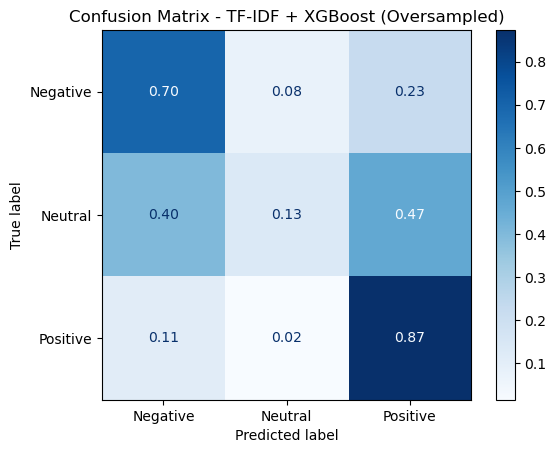

In [78]:
best_y_pred = {
    "TF-IDF + Logistic Regression (Oversampled)": y_pred_tfidf_res,
    "TF-IDF + XGBoost (Oversampled)": y_pred_tfidf_xgb_res,
    "Word2Vec + Logistic Regression (Balanced)": y_pred_w2v_bal,
    "Word2Vec + XGBoost (Balanced)": y_pred_w2v_xgb_bal
}[best_model_name]

cm = confusion_matrix(y_test, best_y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(cmap='Blues', values_format=".2f")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

**Interpretasi:**
- Model mampu mengenali ulasan positif dengan sangat baik (recall 0.87).
- Akurasi pada kelas negatif juga meningkat (0.70) dibanding sebelumnya.
- Namun, kelas netral masih sulit diprediksi karena jumlah datanya sedikit dan karakteristiknya yang ambigu. Hal ini dikarenakan sering kali user menulis review campuran antara pujian terhadap aspek game yang bagus dan keluhan terhadap bug atau fitur tertentu, sehingga model kesulitan membedakan apakah sentimen utamanya positif atau negatif.
- Secara umum, model menjadi lebih balance dan tidak terlalu bias terhadap kelas mayoritas.